In [1]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 40.4 MB/s eta 0:00:00


In [2]:
!apt-get update -qq
!apt-get install fonts-nanum -qq

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118242 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [3]:
import pandas as pd
final_df = pd.read_csv('/content/drive/MyDrive/비타민/서울시 공모전/최종 지수/final_score_4.csv')
final_df.head()

,행정동코드,자치구,행정동,Demand_4,Supply,Final_Score_4
0,11010530,종로구,사직동,32.866667,27.6,22
1,11010540,종로구,삼청동,36.166667,34.4,34
2,11010550,종로구,부암동,35.033333,48.2,47
3,11010560,종로구,평창동,33.600000,52.6,49
4,11010570,종로구,무악동,45.133333,43.5,54


피어슨 상관계수: 0.1297 (p-value: 0.0074)
스피어만 상관계수: 0.1179 (p-value: 0.0150)

순위 차이 평균: 22.73
순위 차이 최대: 193
순위 10위 이상 차이 나는 행정동 수: 294개


/tmp/ipykernel_1041/2089623156.py:36: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1041/2089623156.py:36: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1041/2089623156.py:36: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1041/2089623156.py:36: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1041/2089623156.py:36: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1041/2089623156.py:36: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1041/2089623156.py:36: UserWarning: Glyph 54605 (\N{HANGUL SYLLABLE PIB}) missing from font(s) DejaVu Sans.
  plt.tight_

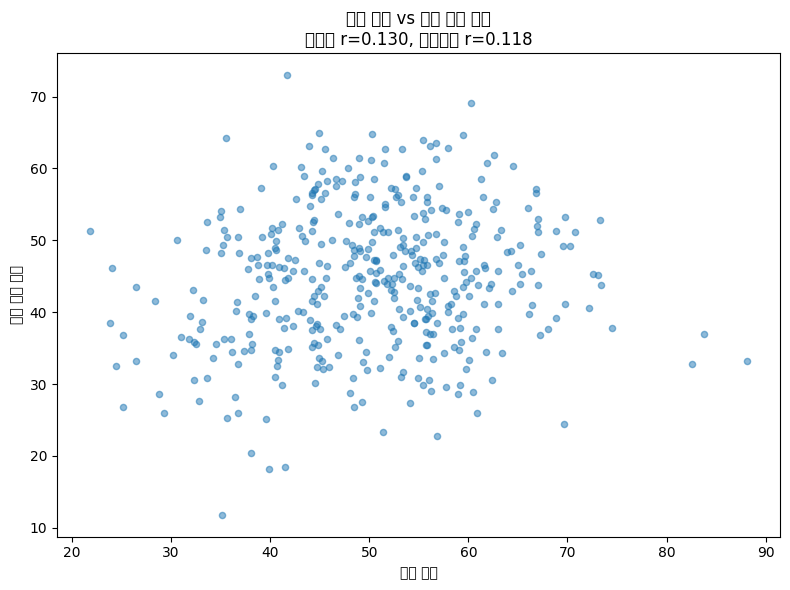

In [4]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# 수요 지수와 공급 결핍 지수 컬럼명 확인 후 수정
demand = final_df['Demand_4']   # 수요 지수 컬럼명
supply = final_df['Supply']   # 공급 결핍 지수 컬럼명

# 1. 피어슨 상관계수
pearson_r, pearson_p = stats.pearsonr(demand, supply)
print(f"피어슨 상관계수: {pearson_r:.4f} (p-value: {pearson_p:.4f})")

# 2. 스피어만 순위 상관계수 (정규분포 가정 없이 순위 기반)
spearman_r, spearman_p = stats.spearmanr(demand, supply)
print(f"스피어만 상관계수: {spearman_r:.4f} (p-value: {spearman_p:.4f})")

# 3. 기하평균 vs 단순합 순위 차이 확인
final_df['geometric_mean'] = np.sqrt(demand * supply)
final_df['simple_sum'] = 0.6 * demand + 0.4 * supply

final_df['rank_geo'] = final_df['geometric_mean'].rank(ascending=False)
final_df['rank_sum'] = final_df['simple_sum'].rank(ascending=False)
final_df['rank_diff'] = (final_df['rank_geo'] - final_df['rank_sum']).abs()

print(f"\n순위 차이 평균: {final_df['rank_diff'].mean():.2f}")
print(f"순위 차이 최대: {final_df['rank_diff'].max():.0f}")
print(f"순위 10위 이상 차이 나는 행정동 수: {(final_df['rank_diff'] >= 10).sum()}개")

# 4. 산점도 시각화
plt.figure(figsize=(8, 6))
plt.scatter(demand, supply, alpha=0.5, s=20)
plt.xlabel('수요 지수')
plt.ylabel('공급 결핍 지수')
plt.title(f'수요 지수 vs 공급 결핍 지수\n피어슨 r={pearson_r:.3f}, 스피어만 r={spearman_r:.3f}')
plt.tight_layout()
plt.show()

In [5]:
import geopandas as gpd
admin_gdf = gpd.read_file('/content/drive/MyDrive/비타민/서울시 공모전/bnd_dong_11_2025_2Q.shp', encoding='utf-8')
admin_gdf.head()

,BASE_DATE,ADM_CD,ADM_NM,geometry
0,20250630,11010530,사직동,"POLYGON ((953553.932 1953335.741, 953555.211 1..."
1,20250630,11010540,삼청동,"POLYGON ((953844.082 1955492.177, 953858.644 1..."
2,20250630,11010550,부암동,"POLYGON ((952490.38 1956548.821, 952497.594 19..."
3,20250630,11010560,평창동,"POLYGON ((953683.828 1959209.871, 953665.283 1..."
4,20250630,11010570,무악동,"POLYGON ((952298.144 1953539.606, 952324.838 1..."


In [6]:
from shapely.ops import unary_union

# '상일2동'을 '상일동'으로 변경
admin_gdf['ADM_NM'] = admin_gdf['ADM_NM'].replace('상일1동', '상일동')

# 상일2동과 강일동 데이터 추출
sangil2 = admin_gdf[admin_gdf['ADM_NM'] == '상일2동']
gangil = admin_gdf[admin_gdf['ADM_NM'] == '강일동']

if not sangil2.empty and not gangil.empty:
    # Geometry 합치기 (두 폴리곤의 합집합)
    new_geometry = unary_union([sangil2['geometry'].values[0], gangil['geometry'].values[0]])

    admin_gdf.loc[admin_gdf['ADM_NM'] == '강일동', 'geometry'] = new_geometry

    # 5. 통합된 상일2동 행 삭제
    admin_gdf = admin_gdf[admin_gdf['ADM_NM'] != '상일2동']

print(admin_gdf[admin_gdf['ADM_NM'] == '상일2동'])
print(admin_gdf[admin_gdf['ADM_NM'] == '강일동'])

Empty GeoDataFrame
Columns: [BASE_DATE, ADM_CD, ADM_NM, geometry]
Index: []
    BASE_DATE    ADM_CD ADM_NM  \
423  20250630  11250750    강일동   

                                              geometry  
423  POLYGON ((971890.728 1951042.68, 971887.303 19...  


In [7]:
import geopandas as gpd

# 1. 데이터 타입 일치 확인 (병합 전 필수 단계)
# 행정동코드와 ADM_CD의 데이터 타입이 다르면 병합되지 않으므로 타입을 맞춰줍니다.
final_df['행정동코드'] = final_df['행정동코드'].astype(str)
admin_gdf['ADM_CD'] = admin_gdf['ADM_CD'].astype(str)

# 2. 병합 수행 (left join을 통해 기존 final_df의 모든 행 유지)
# 필요한 geometry 컬럼과 기준 컬럼만 admin_gdf에서 가져옵니다.
final_gdf = final_df.merge(
    admin_gdf[['ADM_CD', 'geometry']],
    left_on='행정동코드',
    right_on='ADM_CD',
    how='left'
)

final_gdf = gpd.GeoDataFrame(final_gdf, geometry='geometry')
final_gdf.drop(columns=['ADM_CD'], inplace=True)

In [8]:
final_gdf.head()

,행정동코드,자치구,행정동,Demand_4,Supply,Final_Score_4,geometric_mean,simple_sum,rank_geo,rank_sum,rank_diff,geometry
0,11010530,종로구,사직동,32.866667,27.6,22,30.118433,30.76,415.0,417.0,2.0,"POLYGON ((953553.932 1953335.741, 953555.211 1..."
1,11010540,종로구,삼청동,36.166667,34.4,34,35.272274,35.46,392.0,392.0,0.0,"POLYGON ((953844.082 1955492.177, 953858.644 1..."
2,11010550,종로구,부암동,35.033333,48.2,47,41.092660,40.30,335.0,360.0,25.0,"POLYGON ((952490.38 1956548.821, 952497.594 19..."
3,11010560,종로구,평창동,33.600000,52.6,49,42.039981,41.20,316.0,345.0,29.0,"POLYGON ((953683.828 1959209.871, 953665.283 1..."
4,11010570,종로구,무악동,45.133333,43.5,54,44.309141,44.48,277.0,288.0,11.0,"POLYGON ((952298.144 1953539.606, 952324.838 1..."


In [9]:
print(len(final_gdf))

425


In [10]:
final_result = final_gdf.sort_values(by='Final_Score_4', ascending=False).head(20)
final_result

,행정동코드,자치구,행정동,Demand_4,Supply,Final_Score_4,geometric_mean,simple_sum,rank_geo,rank_sum,rank_diff,geometry
327,11210650,관악구,신원동,60.233333,69.1,100,64.514520,63.78,1.0,4.0,3.0,"POLYGON ((949763.16 1942320.72, 949751.371 194..."
320,11210540,관악구,청림동,62.633333,61.9,95,62.265587,62.34,3.0,11.0,8.0,"POLYGON ((952382.696 1943827.922, 952382.473 1..."
251,11160650,강서구,가양2동,73.266667,52.9,95,62.255977,65.12,4.0,2.0,2.0,"POLYGON ((943235.013 1952343.808, 943251.878 1..."
293,11190660,영등포구,신길4동,64.500000,60.3,95,62.364653,62.82,2.0,8.0,6.0,"POLYGON ((948245.871 1945722.835, 948245.974 1..."
263,11170550,구로구,구로4동,66.800000,57.1,94,61.759858,62.92,6.0,6.0,0.0,"POLYGON ((946453.244 1944371.346, 946455.104 1..."
131,11090610,강북구,번2동,59.433333,64.7,94,62.010779,61.54,5.0,17.0,12.0,"POLYGON ((958887.714 1959622.929, 958888.69 19..."
137,11090700,강북구,미아동,61.900000,60.7,93,61.297064,61.42,8.0,19.0,11.0,"POLYGON ((958301.054 1959603.612, 958292.609 1..."
11,11010680,종로구,창신2동,66.833333,56.6,93,61.504200,62.74,7.0,9.0,2.0,"POLYGON ((956818.568 1953433.269, 956819.4 195..."
337,11210810,관악구,난곡동,69.733333,53.3,92,60.965455,63.16,9.0,5.0,4.0,"POLYGON ((949301.687 1941719.769, 949323.644 1..."
226,11150570,양천구,신월1동,57.966667,62.8,91,60.334954,59.90,10.0,25.0,15.0,"POLYGON ((941396.798 1947618.078, 941230.994 1..."


--- 3.4.1 행정동별 분포 요약 ---
count    425.000000
mean      60.025882
std       17.373309
min        0.000000
25%       49.000000
50%       61.000000
75%       72.000000
max      100.000000
Name: Final_Score_4, dtype: float64

--- 수요 지수 상위 10개 행정동 ---
      자치구   행정동  Final_Score_4
327   관악구   신원동            100
320   관악구   청림동             95
251   강서구  가양2동             95
293  영등포구  신길4동             95
263   구로구  구로4동             94
131   강북구   번2동             94
137   강북구   미아동             93
11    종로구  창신2동             93
337   관악구   난곡동             92
226   양천구  신월1동             91

--- 3.4.2 자치구별 요약 통계 ---
           평균점수       표준편차  최댓값      지니계수
자치구                                      
강북구   80.307692   9.213980   94  0.062629
관악구   74.809524  11.526574  100  0.083356
도봉구   73.642857  11.711974   90  0.086393
노원구   69.263158  14.023164   89  0.108223
은평구   67.625000  11.757976   86  0.085259
양천구   65.611111  17.836311   91  0.145122
중랑구   65.250000  13.112335   87  0.111351
구로구   64

/tmp/ipykernel_1041/287697106.py:54: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(final_gdf)



--- Global Moran's I 결과 ---
Moran's I: 0.3679
P-value: 0.0010

--- LISA 분석: High-High(핫스팟) 지역 수 ---
43 개 행정동


/tmp/ipykernel_1041/287697106.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


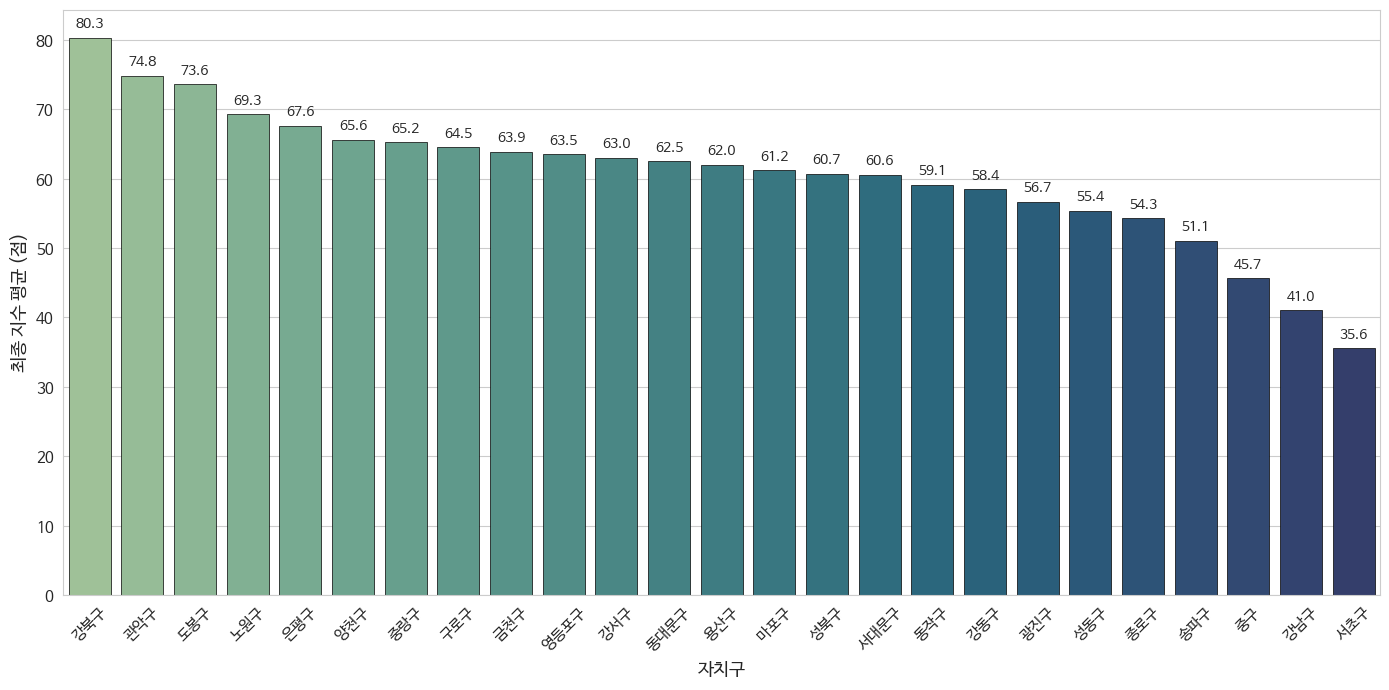

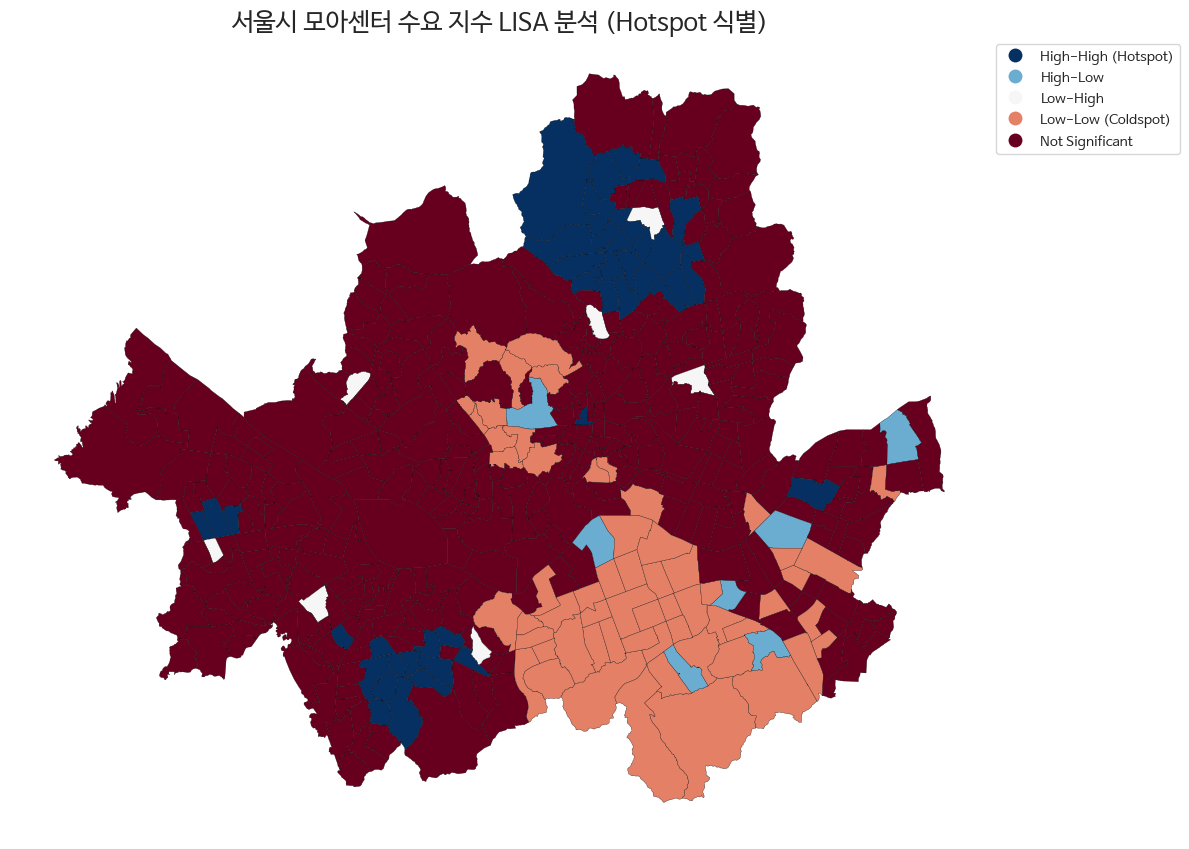

In [11]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local
import matplotlib.font_manager as fm


# 시각화 한글 폰트 설정 (환경에 맞게 수정 필요)
# 1. 폰트 경로 정의 (코랩 표준 경로)
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
# 개별 요소에 적용할 폰트 객체 생성
font_p = fm.FontProperties(fname=font_path)

# ---------------------------------------------------------
# [3.4.1] 행정동별 수요 지수 분포 분석
# ---------------------------------------------------------
print("--- 3.4.1 행정동별 분포 요약 ---")
desc_stats = final_gdf['Final_Score_4'].describe()
print(desc_stats)

# Top 10 행정동 리스트 추출
top10_dongs = final_gdf.sort_values(by='Final_Score_4', ascending=False).head(10)
print("\n--- 수요 지수 상위 10개 행정동 ---")
print(top10_dongs[['자치구', '행정동', 'Final_Score_4']])

# ---------------------------------------------------------
# [3.4.2] 자치구별 수요 집중도 비교
# ---------------------------------------------------------
# 지니 계수 계산 함수 정의
def get_gini(x):
    diffsum = 0
    for i, xi in enumerate(x):
        for j, xj in enumerate(x):
            diffsum += abs(xi - xj)
    return diffsum / (2 * len(x)**2 * np.mean(x))

print("\n--- 3.4.2 자치구별 요약 통계 ---")
gu_analysis = final_gdf.groupby('자치구')['Final_Score_4'].agg([
    ('평균점수', 'mean'),
    ('표준편차', 'std'),
    ('최댓값', 'max'),
    ('지니계수', get_gini)
]).sort_values(by='평균점수', ascending=False)

print(gu_analysis)

# ---------------------------------------------------------
# [3.4.3] 고수요 지역의 공간적 패턴 분석 (Moran's I & LISA)
# ---------------------------------------------------------
# 1. 공간 가중치 행렬 생성 (Queen 방식)
w = Queen.from_dataframe(final_gdf)
w.transform = 'R' # 행 정문화(Row-standardization)

# 2. Global Moran's I 계산 (전체적 군집도)
moran_global = Moran(final_gdf['Final_Score_4'], w)
print(f"\n--- Global Moran's I 결과 ---")
print(f"Moran's I: {moran_global.I:.4f}")
print(f"P-value: {moran_global.p_sim:.4f}")

# 3. Local Moran's I (LISA) 분석 (국지적 핫스팟 식별)
lisa = Moran_Local(final_gdf['Final_Score_4'], w)

# LISA 결과 매핑 (HH, LH, LL, HL)
# q=1:HH, 2:LH, 3:LL, 4:HL
final_gdf['lisa_cluster'] = lisa.q
final_gdf['lisa_p'] = lisa.p_sim

# 유의미한(p < 0.05) 클러스터 레이블링
def label_lisa(row):
    if row['lisa_p'] > 0.05:
        return 'Not Significant'
    if row['lisa_cluster'] == 1: return 'High-High (Hotspot)'
    if row['lisa_cluster'] == 2: return 'Low-High'
    if row['lisa_cluster'] == 3: return 'Low-Low (Coldspot)'
    if row['lisa_cluster'] == 4: return 'High-Low'
    return 'Not Significant'

final_gdf['lisa_label'] = final_gdf.apply(label_lisa, axis=1)

print("\n--- LISA 분석: High-High(핫스팟) 지역 수 ---")
print(final_gdf[final_gdf['lisa_label'] == 'High-High (Hotspot)']['행정동'].count(), "개 행정동")

# ---------------------------------------------------------
# [시각화 1] 자치구별 평균 점수 비교 차트
# ---------------------------------------------------------
import seaborn as sns

# 1. 시각화 스타일 및 폰트 설정
sns.set_style("whitegrid") # 배경에 깔끔한 그리드 추가
plt.figure(figsize=(14, 7))

# 2. 막대 그래프 생성 (palette 변경: 'crest'는 신뢰감을 주는 블루-그린 계열)
# 점수가 높을수록 짙은 색이 되도록 설정
ax = sns.barplot(
    x=gu_analysis.index,
    y=gu_analysis['평균점수'],
    palette='crest',
    edgecolor='black',
    linewidth=0.5
)

# 3. 제목 및 라벨 설정 (그림 번호 포함)
plt.xlabel('자치구', fontproperties=font_p, fontsize=13)
plt.ylabel('최종 지수 평균 (점)', fontproperties=font_p, fontsize=13)

# 4. 축 눈금 폰트 적용
plt.xticks(rotation=45, fontproperties=font_p, fontsize=11)
plt.yticks(fontproperties=font_p, fontsize=11)

# 5. 막대 상단에 점수 텍스트 표시 (선택 사항: 가독성 향상)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontproperties=font_p, fontsize=10)

# 여백 조절 및 출력
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# [시각화 2] LISA 클러스터 지도 (Hotspot 분석)
# ---------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# 지도 시각화
final_gdf.plot(column='lisa_label',
               categorical=True,
               legend=True,
               ax=ax,
               cmap='RdBu_r',
               edgecolor='black',
               linewidth=0.2,
               legend_kwds={'loc': 'upper left', 'bbox_to_anchor': (1, 1)})

# 제목 및 범례 폰트 적용
ax.set_title('서울시 모아센터 수요 지수 LISA 분석 (Hotspot 식별)', fontproperties=font_p, fontsize=18)
ax.axis('off')

# 범례 폰트 수정을 위해 범례 객체 접근
legend = ax.get_legend()
if legend:
    for text in legend.get_texts():
        text.set_fontproperties(font_p)

plt.tight_layout()
plt.show()

--- 공간적 자기상관 (Moran's I) ---

           Model          Moran's I     P-value      gini       Std Dev      IQR    Min    Max

3  Final_Score_4     0.3966        0.001      0.1994     19.486      26.0      0      100










In [12]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# 1. 데이터 리스트 생성 (이름, 행정동, 위도, 경도)
moa_data = [
    ["(도봉구) 방학2동 모아센터", "방학2동", 37.664628, 127.033887],
    ["(도봉구) 도봉2동 모아센터", "도봉2동", 37.675204, 127.044898],
    ["(도봉구) 창2동 모아센터", "창2동", 37.640516, 127.036706],
    ["(중구) 다산성곽마을 모아센터", "다산동", 37.554944, 127.005598],
    ["(중구) 장충동 모아센터", "장충동", 37.561869, 127.007856],
    ["(은평구) 산골마을 모아센터", "녹번동", 37.598958, 126.938467],
    ["(은평구) 산새마을 모아센터", "신사2동", 37.596334, 126.905720],
    ["(은평구) 향림마을 모아센터", "불광동", 37.627051, 126.927154],
    ["(은평구) 수리마을 모아센터", "불광동", 37.622225, 126.931923],
    ["(성북구) 한천마을 모아센터", "석관동", 37.612920, 127.061405],
    ["(성북구) 소리마을 모아센터", "길음동", 37.608639, 127.022045],
    ["(금천구) 박미사랑 모아센터", "시흥3", 37.440493, 126.907541],
    ["(강북구) 어진마을 모아센터", "수유", 37.635751, 127.015926],
    ["(관악구) 굴참마을 모아센터", "난곡동", 37.471117, 126.917805]
]

# 2. DataFrame 생성
columns = ['모아센터', '행정동', 'lat', 'lon']
df_moa = pd.DataFrame(moa_data, columns=columns)

# 3. Geometry 생성 (경도, 위도 순서로 Point 객체 생성)
geometry = [Point(xy) for xy in zip(df_moa['lon'], df_moa['lat'])]

# 4. GeoDataFrame 변환 (WGS84 좌표계: EPSG:4326 설정)
moa_gdf = gpd.GeoDataFrame(df_moa, geometry=geometry, crs="EPSG:4326")

# 결과 확인
print(moa_gdf.head())

               모아센터   행정동        lat         lon                    geometry
0   (도봉구) 방학2동 모아센터  방학2동  37.664628  127.033887  POINT (127.03389 37.66463)
1   (도봉구) 도봉2동 모아센터  도봉2동  37.675204  127.044898    POINT (127.0449 37.6752)
2    (도봉구) 창2동 모아센터   창2동  37.640516  127.036706  POINT (127.03671 37.64052)
3  (중구) 다산성곽마을 모아센터   다산동  37.554944  127.005598   POINT (127.0056 37.55494)
4     (중구) 장충동 모아센터   장충동  37.561869  127.007856  POINT (127.00786 37.56187)


In [13]:
# moa_gdf를 다른 데이터프레임의 좌표계와 동일하게 맞추기
moa_gdf = moa_gdf.to_crs(final_gdf.crs)

<Axes: >

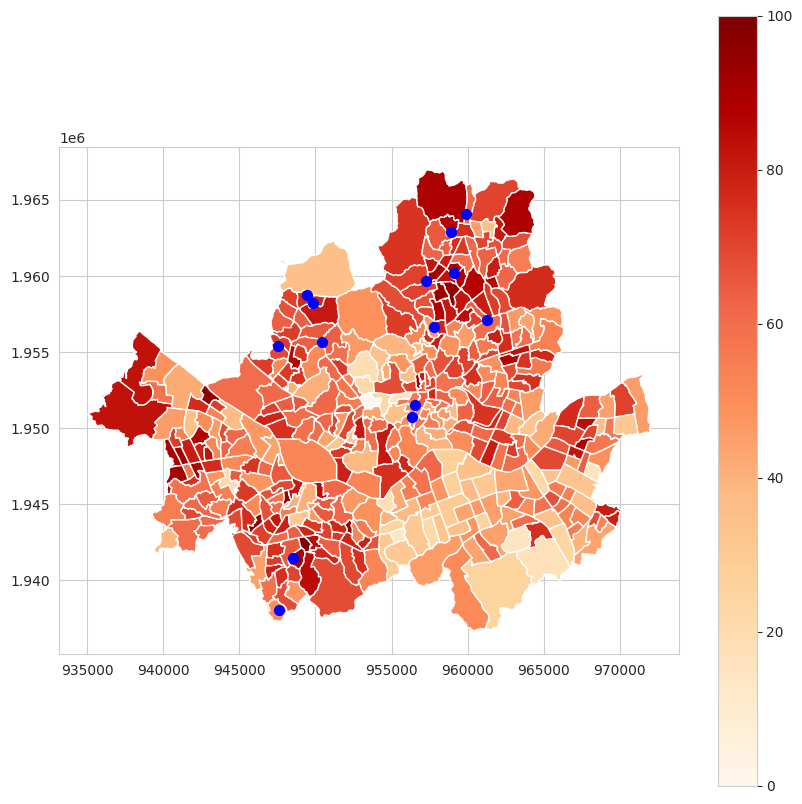

In [14]:
base = final_gdf.plot(column='Final_Score_4', cmap='OrRd', legend=True, figsize=(10, 10))
moa_gdf.plot(ax=base, color='blue', markersize=50, label='Moa Centers')

In [15]:
import pandas as pd
import geopandas as gpd
from libpysal.weights import Queen, lag_spatial

# 1. 500m 버퍼 중복 여부 확인 컬럼 생성
# moa_gdf와 final_gdf 모두 EPSG:5179(미터 단위)라고 가정합니다.
moa_m = moa_gdf.to_crs(epsg=5179)
final_gdf_m = final_gdf.to_crs(epsg=5179)

# 기존 모아센터의 500m 통합 버퍼 생성
moa_buffer_500 = moa_m.geometry.buffer(500).union_all()

# 중심점이 버퍼 안에 포함되는지 체크 (True/False)
final_gdf['is_within_500m'] = final_gdf_m.geometry.centroid.within(moa_buffer_500)

# HVI_index가 zero인 경우 제외
hvi_zero_dongs=['일원본동', '소공동', '신정6동', '잠실7동', '둔촌1동', '가양3동', '문정2동', '반포본동', '상계8동', '상계9동', '오륜동', '잠실2동', '잠실6동',' 을지로동']

# 'zero_HVI' 컬럼을 기본적으로 False로 초기화
final_gdf['zero_HVI'] = False

# 리스트에 포함된 행정동의 'zero_HVI' 값을 True로 변경
# .isin() 함수를 사용하여 리스트 포함 여부를 효율적으로 체크합니다.
final_gdf.loc[final_gdf['행정동'].isin(hvi_zero_dongs), 'zero_HVI'] = True

# 3. 결과 확인 (True인 행들만 출력)
print(final_gdf[final_gdf['zero_HVI'] == True][['자치구', '행정동', 'zero_HVI']])


# 2. Queen 인접성 기반 인접 행정동 평균 점수 산출
# Queen 가중치: 변(Edge)이나 꼭짓점(Vertex)을 공유하는 모든 인접 동을 포함
w = Queen.from_dataframe(final_gdf)

# 행 표준화(Row-standardized)를 통해 합계가 아닌 '평균'을 계산하도록 설정
w.transform = 'R'

# 인접 행정동의 Final_Score_4 평균값 계산하여 매핑
# w.lag_spatial은 인접 지역 점수의 가중 평균을 산출함
final_gdf['Neighbor_Avg_Score'] = lag_spatial(w, final_gdf['Final_Score_4'])

# 3. Top-20 추출 (최종 점수 기준)
# 우선순위 확인을 위해 상위 20개를 뽑아 새로운 컬럼들을 확인합니다.
top_20_candidates = final_gdf.sort_values(by='Final_Score_4', ascending=False).head(20).copy()

# 4. 결과 확인 (동점자 처리를 위한 데이터 프레임)
# 이제 Final_Score_4가 같더라도 Neighbor_Avg_Score가 높은 지역을 우선할 수 있습니다.
top_20_candidates[['행정동', 'Final_Score_4', 'Neighbor_Avg_Score', 'is_within_500m', 'zero_HVI']]

     자치구   행정동  zero_HVI
17    중구   소공동      True
169  노원구  상계8동      True
170  노원구  상계9동      True
236  양천구  신정6동      True
252  강서구  가양3동      True
345  서초구  반포본동      True
372  강남구  일원본동      True
388  송파구   오륜동      True
398  송파구  문정2동      True
401  송파구  잠실6동      True
402  송파구  잠실7동      True
403  송파구  잠실2동      True
418  강동구  둔촌1동      True


/tmp/ipykernel_1041/857110113.py:32: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(final_gdf)


,행정동,Final_Score_4,Neighbor_Avg_Score,is_within_500m,zero_HVI
327,신원동,100,77.714286,False,False
320,청림동,95,67.250000,False,False
251,가양2동,95,56.666667,False,False
293,신길4동,95,61.571429,False,False
263,구로4동,94,68.600000,False,False
131,번2동,94,85.600000,False,False
137,미아동,93,79.142857,False,False
11,창신2동,93,63.000000,False,False
337,난곡동,92,79.750000,True,False
226,신월1동,91,77.600000,False,False


In [16]:
# 1. 기존 센터 500m 이내 지역 제외 (False인 것만 필터링)
filtered_candidates = final_gdf[
    (final_gdf['is_within_500m'] == False) &
    (final_gdf['zero_HVI'] == False)
].copy()

# 2. 계층적 정렬 적용
# 1순위: Final_Score_4 (내림차순)
# 2순위: Neighbor_Avg_Score (내림차순) - 점수가 같을 때 변별력 확보
final_selection_14 = filtered_candidates.sort_values(
    by=['Final_Score_4', 'Neighbor_Avg_Score'],
    ascending=[False, False]
).head(14)

# 3. 결과 확인
print(f"--- 최종 선정된 신규 모아센터 후보지 14개소 ---")
print(final_selection_14[['자치구', '행정동', 'Final_Score_4', 'Neighbor_Avg_Score']].reset_index(drop=True))

# (옵션) 최종 리스트를 CSV나 Excel로 저장하고 싶다면:
# final_selection_14.to_csv('final_14_candidates.csv', index=False, encoding='cp949')

--- 최종 선정된 신규 모아센터 후보지 14개소 ---
     자치구     행정동  Final_Score_4  Neighbor_Avg_Score
0    관악구     신원동            100           77.714286
1    관악구     청림동             95           67.250000
2   영등포구    신길4동             95           61.571429
3    강서구    가양2동             95           56.666667
4    강북구     번2동             94           85.600000
5    구로구    구로4동             94           68.600000
6    강북구     미아동             93           79.142857
7    종로구    창신2동             93           63.000000
8    양천구    신월1동             91           77.600000
9    강북구    수유3동             90           81.200000
10   양천구    신월7동             90           70.833333
11   도봉구     창3동             89           82.333333
12   노원구  상계3·4동             89           73.000000
13   도봉구    도봉1동             89           72.400000


In [17]:
import folium

import json

import pandas as pd

import geopandas as gpd



# 1. 지도 중심 설정

m4 = folium.Map(location=[37.5665, 126.9780], zoom_start=11, tiles='cartodbpositron')



# 2. final_gdf 좌표계 변환 및 Top-20 산출

# EPSG:5179 -> 4326 변환

final_gdf_4326 = final_gdf.to_crs(epsg=4326)



# 서울 전체 행정동 순위 계산

final_gdf_4326['순위'] = final_gdf_4326['Final_Score_4'].rank(ascending=False, method='min').astype(int)



# 상위 20개 행정동 추출 및 중심점 계산

top_20_gdf = final_gdf_4326.sort_values(by='Final_Score_4', ascending=False).head(20).copy()

top_20_gdf['centroid'] = top_20_gdf.geometry.centroid



# 3. 단계구분도(Choropleth)용 전처리

temp_gdf = final_gdf_4326[['자치구', '행정동', 'Final_Score_4', '순위', 'geometry']].copy()

temp_gdf['행정동'] = temp_gdf['행정동'].astype(str).str.strip()

geo_json_dict = json.loads(temp_gdf.to_json())



# 4. 단계구분도 추가

folium.Choropleth(

    geo_data=geo_json_dict,

    data=temp_gdf,

    columns=['행정동', 'Final_Score_4'],

    key_on='feature.properties.행정동',

    fill_color='OrRd',

    fill_opacity=0.6,

    line_opacity=0.2,

    legend_name='최종 수요 지수 (Final_Score_4)'

).add_to(m4)



# 5. 행정동 경계 툴팁

folium.GeoJson(

    geo_json_dict,

    style_function=lambda x: {'fillColor': 'transparent', 'color': 'transparent'},

    tooltip=folium.GeoJsonTooltip(

        fields=['자치구', '행정동', 'Final_Score_4', '순위'],

        aliases=['자치구: ', '행정동: ', '최종 지수: ', '순위: '],

        localize=True

    )

).add_to(m4)



# 6. 기존 모아센터 시각화 (요청 사항: 파란색 적용)

moa_wgs = moa_gdf.to_crs(epsg=4326)

for _, row in moa_wgs.iterrows():

    # 서비스 권역 (500m) - 파란색 계열

    folium.Circle(

        location=[row.geometry.y, row.geometry.x],

        radius=500,

        color='#2980b9',

        fill=True,

        fill_opacity=0.1,

        weight=1.5

    ).add_to(m4)



    # 센터 위치 마커 및 툴팁 - 파란색

    folium.CircleMarker(

        location=[row.geometry.y, row.geometry.x],

        radius=5,

        color='#2980b9',

        fill=True,

        fill_color='#2980b9',

        tooltip=folium.Tooltip(f"<b>기존 모아센터: {row['모아센터']}</b>", sticky=True)

    ).add_to(m4)



# 7. Top-20 행정동 중심점 시각화 (요청 사항: 검정색 적용)

for _, row in top_20_gdf.iterrows():

    # Top-20 지역 1km 버퍼 (검정색 점선으로 차별화)

    folium.Circle(

        location=[row.centroid.y, row.centroid.x],

        radius=500,

        color='black',

        fill=False,

        weight=1.5,

        dash_array='5, 5', # 점선 스타일 적용

        tooltip=folium.Tooltip(f"<b>{row['행정동']} 수요권역 (1km)</b>")

    ).add_to(m4)



    # Top-20 중심점 마커

    folium.CircleMarker(

        location=[row.centroid.y, row.centroid.x],

        radius=4, color='black', fill=True, fill_color='black',

        tooltip=folium.Tooltip(

            f"<b>[수요 {row['순위']}위] {row['행정동']}</b><br>"

            f"최종 지수: {row['Final_Score_4']:.1f}점",

            sticky=True

        )

    ).add_to(m4)



# 8. 결과 저장

m4.save('seoul_moa_full_comparison.html')

m4

Output hidden; open in https://colab.research.google.com to view.

In [18]:
import folium
import json
import pandas as pd
import geopandas as gpd

# 1. 지도 중심 설정 (서울 중심)
m4 = folium.Map(location=[37.5665, 126.9780], zoom_start=11, tiles='cartodbpositron')

# 2. 좌표계 변환 (EPSG:5179 -> 4326)
# 최종 선정된 14개소 데이터 사용
final_14_wgs = final_selection_14.to_crs(epsg=4326)

# 중심점(Centroid) 계산
final_14_wgs['centroid'] = final_14_wgs.geometry.centroid

# 3. 단계구분도(Choropleth) 및 툴팁용 데이터 생성
# 전체 행정동의 순위와 점수를 보여주기 위해 final_gdf_4326(전체 데이터)를 활용합니다.
all_gdf_4326 = final_gdf.to_crs(epsg=4326)
all_gdf_4326['순위'] = all_gdf_4326['Final_Score_4'].rank(ascending=False, method='min').astype(int)
all_gdf_4326['행정동'] = all_gdf_4326['행정동'].astype(str).str.strip()

geo_json_dict = json.loads(all_gdf_4326.to_json())

# 4. 단계구분도 추가 (배경: 서울 전체 수요 지수)
folium.Choropleth(
    geo_data=geo_json_dict,
    data=all_gdf_4326,
    columns=['행정동', 'Final_Score_4'],
    key_on='feature.properties.행정동',
    fill_color='OrRd',
    fill_opacity=0.6,
    line_opacity=0.2,
    legend_name='최종 지수'
).add_to(m4)

# 5. 행정동 경계 툴팁 (마우스 오버 시 정보 표시)
folium.GeoJson(
    geo_json_dict,
    style_function=lambda x: {'fillColor': 'transparent', 'color': 'transparent'},
    tooltip=folium.GeoJsonTooltip(
        fields=['자치구', '행정동', 'Final_Score_4', '순위'],
        aliases=['자치구: ', '행정동: ', '최종 지수: ', '서울시 순위: '],
        localize=True
    )
).add_to(m4)

# 6. 기존 모아센터 시각화 (파란색 실선 및 마커)
moa_wgs = moa_gdf.to_crs(epsg=4326)
for _, row in moa_wgs.iterrows():
    # 서비스 권역 (500m)
    folium.Circle(
        location=[row.geometry.y, row.geometry.x],
        radius=500,
        color='#2980b9',
        fill=True,
        fill_opacity=0.1,
        weight=1.5
    ).add_to(m4)

    # 센터 위치 마커
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=5,
        color='#2980b9',
        fill=True,
        fill_color='#2980b9',
        tooltip=folium.Tooltip(f"<b>기존 모아센터: {row['모아센터']}</b>", sticky=True)
    ).add_to(m4)

# 7. 최종 후보지 14개소 시각화 (검정색 점선 및 마커)
for _, row in final_14_wgs.iterrows():
    # 후보지 마커
    folium.CircleMarker(
        location=[row.centroid.y, row.centroid.x],
        radius=3,
        color='black',
        tooltip=folium.Tooltip(
            f"<b>[추천 후보지] {row['행정동']}</b><br>"
            f"최종 지수: {row['Final_Score_4']:.1f}점<br>"
            f"인접 평균: {row['Neighbor_Avg_Score']:.1f}점",
            sticky=True
        )
    ).add_to(m4)

# 8. 결과 저장 및 출력
m4.save('seoul_moa_final_14_recommendations.html')
m4

Output hidden; open in https://colab.research.google.com to view.

/tmp/ipykernel_1041/302540385.py:32: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  relevant_buffers = moa_m[moa_m.buffer_500.intersects(combined_area.unary_union)]
/tmp/ipykernel_1041/302540385.py:32: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  relevant_buffers = moa_m[moa_m.buffer_500.intersects(combined_area.unary_union)]


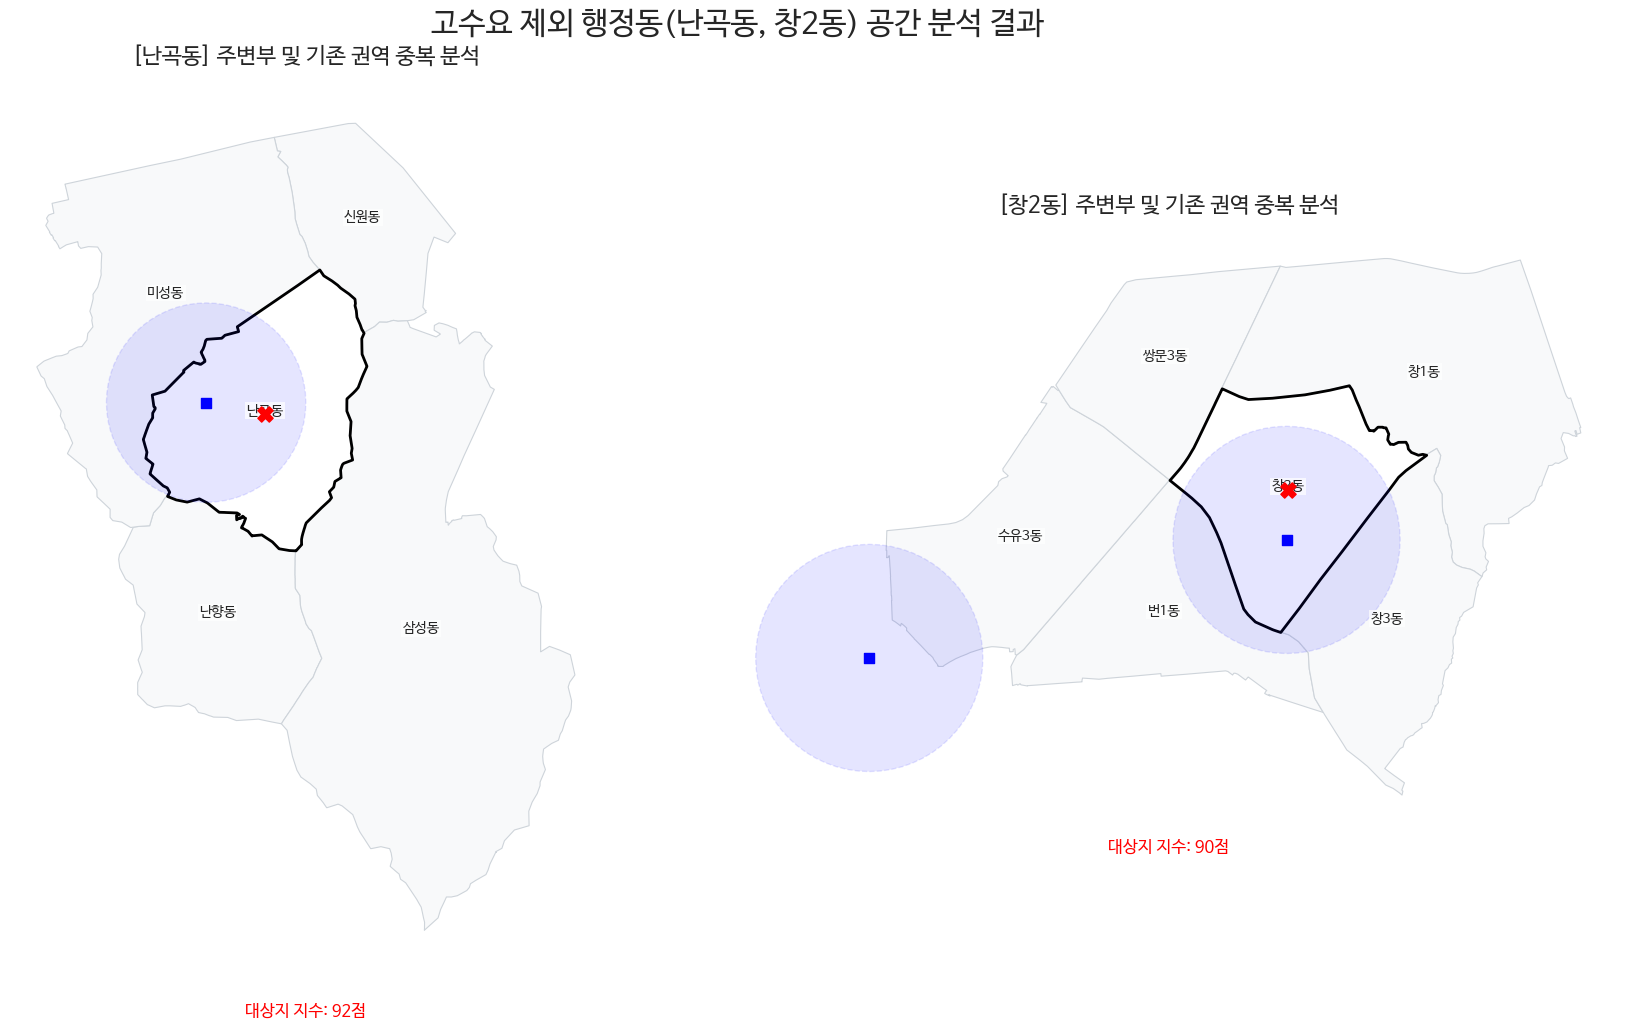

In [19]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import geopandas as gpd

# 1. 폰트 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_p = fm.FontProperties(fname=font_path)
plt.rc('font', family='NanumBarunGothic')

# 2. 데이터 준비 (EPSG:5179 미터 단위 좌표계 기준)
final_m = final_gdf.to_crs(epsg=5179)
moa_m = moa_gdf.to_crs(epsg=5179)

# 기존 모아센터 500m 버퍼 생성
moa_m['buffer_500'] = moa_m.geometry.buffer(500)

# 분석 대상 행정동
target_dongs = ['난곡동', '창2동']

# 3. 시각화 함수 정의
def plot_neighborhood_analysis(dong_name, ax):
    # 중심이 되는 행정동 추출
    center_dong = final_m[final_m['행정동'] == dong_name]

    # 주변 인접 행정동 추출 (경계가 맞닿은 모든 동)
    neighbors = final_m[final_m.geometry.touches(center_dong.geometry.iloc[0])]

    # 시각화 범위 설정을 위한 결합 데이터
    combined_area = gpd.pd.concat([center_dong, neighbors])

    # 해당 범위 내에 있는 기존 모아센터 버퍼 필터링
    relevant_buffers = moa_m[moa_m.buffer_500.intersects(combined_area.unary_union)]

    # 1) 주변 행정동 그리기
    neighbors.plot(ax=ax, color='#f8f9fa', edgecolor='#ced4da', linewidth=0.8)

    # 2) 대상 행정동 그리기
    center_dong.plot(ax=ax, color='white', edgecolor='black', linewidth=2.0)

    # 3) 기존 센터 500m 버퍼 그리기
    if not relevant_buffers.empty:
        relevant_buffers.buffer_500.plot(ax=ax, color='blue', alpha=0.1, edgecolor='blue', linestyle='--')
        relevant_buffers.plot(ax=ax, color='blue', markersize=60, marker='s', zorder=4)

    # 4) 행정동 이름 텍스트 표시
    for _, row in combined_area.iterrows():
        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, row['행정동'],
                fontproperties=font_p, fontsize=10, ha='center',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    # 5) 대상 동의 중심점(Centroid) 표시
    center_centroid = center_dong.geometry.centroid
    center_centroid.plot(ax=ax, color='red', markersize=120, marker='X', zorder=5)

    # 그래프 설정
    ax.set_title(f"[{dong_name}] 주변부 및 기존 권역 중복 분석", fontproperties=font_p, fontsize=16, pad=15)
    ax.set_axis_off()

    # 범례 및 정보 추가
    score = center_dong['Final_Score_4'].values[0]
    ax.annotate(f"대상지 지수: {score}점", xy=(0.5, -0.05), xycoords='axes fraction',
                fontproperties=font_p, fontsize=12, ha='center', color='red', weight='bold')

# 4. 이미지 생성
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

for i, dong in enumerate(target_dongs):
    plot_neighborhood_analysis(dong, axes[i])

plt.tight_layout()
plt.suptitle("고수요 제외 행정동(난곡동, 창2동) 공간 분석 결과", fontproperties=font_p, fontsize=22, y=1.02)
plt.show()